In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import resample
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBRegressor
import os
from lightgbm import LGBMRegressor
#from catboost import CatBoostClassifier


# Exploring Dataset

In [2]:
df = pd.read_csv("kc_house_data.csv")
#df = df.drop(columns=['Flight']) #flight id is irrelevant

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nDescribe:\n", df.describe())
print(df.columns)

Shape: (21613, 21)

Dtypes:
 id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Missing Values:
 id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

D

In [181]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["log_price"]       = np.log1p(df["price"])
    df["age"]             = 2015 - df["yr_built"]
    df["was_renovated"]   = df["yr_renovated"].notna().astype(int)
    df["price_per_sqft"]  = df["price"] / df["sqft_living"]
    df["basement_exists"] = (df["sqft_basement"] > 0).astype(int)
    print("New features added: log_price, age, was_renovated, price_per_sqft, basement_exists")
    return df

In [195]:
def plot_price_distribution(df: pd.DataFrame):
    plt.figure(figsize=(10, 5))
    plt.hist(df["price"], bins=60, color="steelblue", edgecolor="white")
    plt.title("Housing Price Distribution")
    plt.xlabel("Price ($)")
    plt.ylabel("Count")
    plt.show()

In [196]:
def plot_price_vs_sqft(df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        df["sqft_living"], df["price"],
        c=df["grade"], cmap="viridis", alpha=0.6, edgecolors="none"
    )
    plt.colorbar(scatter, label="Grade")
    plt.title("Price vs Living Area by Grade")
    plt.xlabel("Sqft Living")
    plt.ylabel("Price ($)")
    plt.show()

In [197]:
def plot_price_by_bedrooms(df: pd.DataFrame):
    bed_price = df.groupby("bedrooms")["price"].median()
    plt.figure(figsize=(8, 5))
    plt.bar(bed_price.index, bed_price.values, color="steelblue", edgecolor="white")
    plt.title("Median Price by Bedrooms")
    plt.xlabel("Bedrooms")
    plt.ylabel("Median Price ($)")
    plt.show()

In [198]:
def plot_correlation_heatmap(df: pd.DataFrame):
    num_cols = [
        "price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot",
        "floors", "waterfront", "view", "condition", "grade",
        "sqft_above", "sqft_basement", "yr_built", "sqft_living15", "sqft_lot15"
    ]
    corr = df[num_cols].corr().round(2)
    plt.figure(figsize=(13, 10))
    sns.heatmap(
        corr, annot=True, fmt=".2f", cmap="RdBu_r",
        center=0, linewidths=0.5, annot_kws={"size": 8}
    )
    plt.title("Feature Correlation Heatmap")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.show()

In [199]:
def plot_price_by_waterfront(df: pd.DataFrame):
    groups = [
        df.loc[df["waterfront"] == 0, "price"],
        df.loc[df["waterfront"] == 1, "price"]
    ]
    plt.figure(figsize=(8, 5))
    plt.boxplot(groups, labels=["No Waterfront", "Waterfront"], patch_artist=True,
                boxprops=dict(facecolor="steelblue", color="navy"),
                medianprops=dict(color="white", linewidth=2))
    plt.title("Price Distribution: Waterfront vs Non-Waterfront")
    plt.xlabel("Waterfront Status")
    plt.ylabel("Price ($)")
    plt.show()

In [205]:
def plot_price_by_grade(df: pd.DataFrame):
    grade_price = df.groupby("grade")["price"].median()
    plt.figure(figsize=(9, 5))
    plt.plot(grade_price.index, grade_price.values, marker="o", color="steelblue", linewidth=2)
    plt.fill_between(grade_price.index, grade_price.values, alpha=0.15, color="steelblue")
    plt.title("Median Price Rises with Grade")
    plt.xlabel("Grade")
    plt.ylabel("Median Price ($)")
    plt.show()

In [200]:
def plot_yr_built_distribution(df: pd.DataFrame):
    df_dec = df.copy()
    df_dec["decade"] = (df_dec["yr_built"] // 10) * 10
    decade_counts = df_dec.groupby("decade").size()
    plt.figure(figsize=(12, 5))
    plt.bar(decade_counts.index, decade_counts.values, width=8,
            color="steelblue", edgecolor="white")
    plt.title("Houses Built per Decade")
    plt.xlabel("Decade Built")
    plt.ylabel("Count")
    plt.show()

In [201]:
def plot_geo_price(df: pd.DataFrame):
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        df["long"], df["lat"],
        c=df["price"], cmap="plasma", alpha=0.6,
        edgecolors="none", s=15
    )
    plt.colorbar(scatter, label="Price ($)")
    plt.title("Geographic Distribution of Prices")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

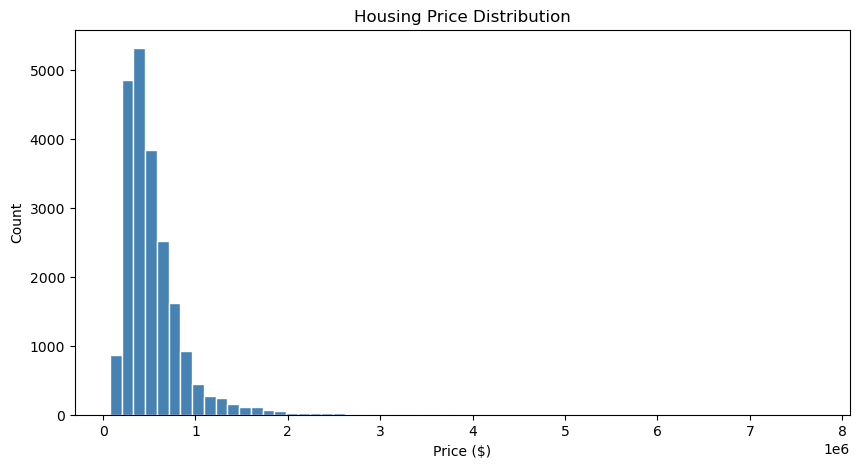

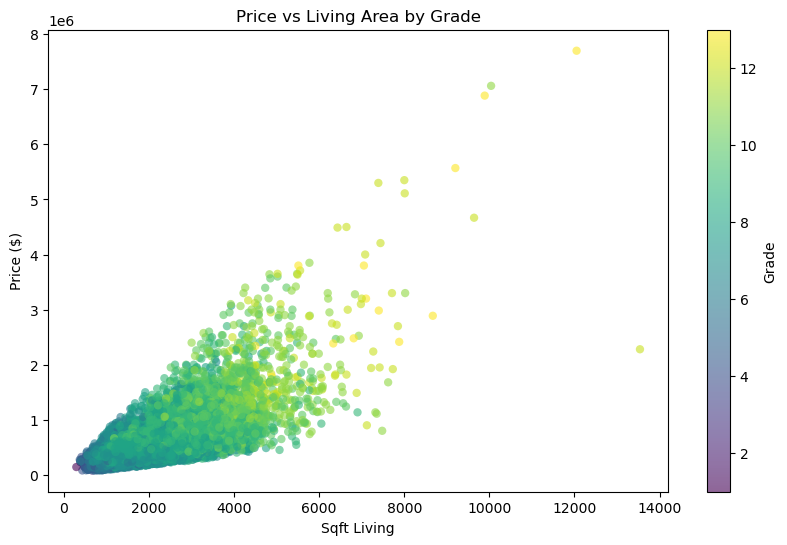

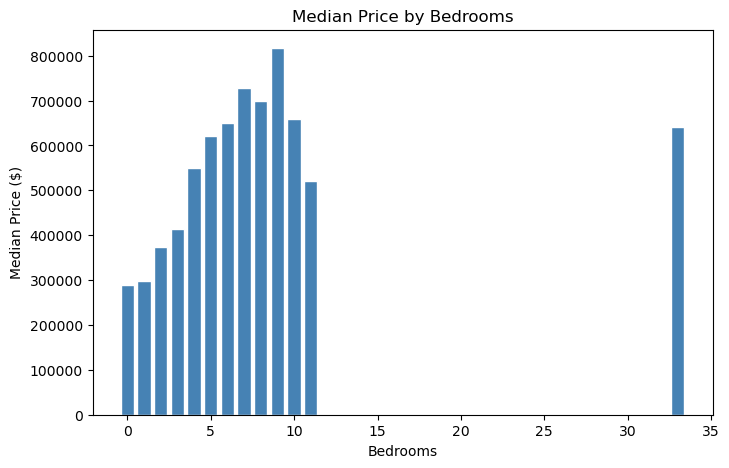

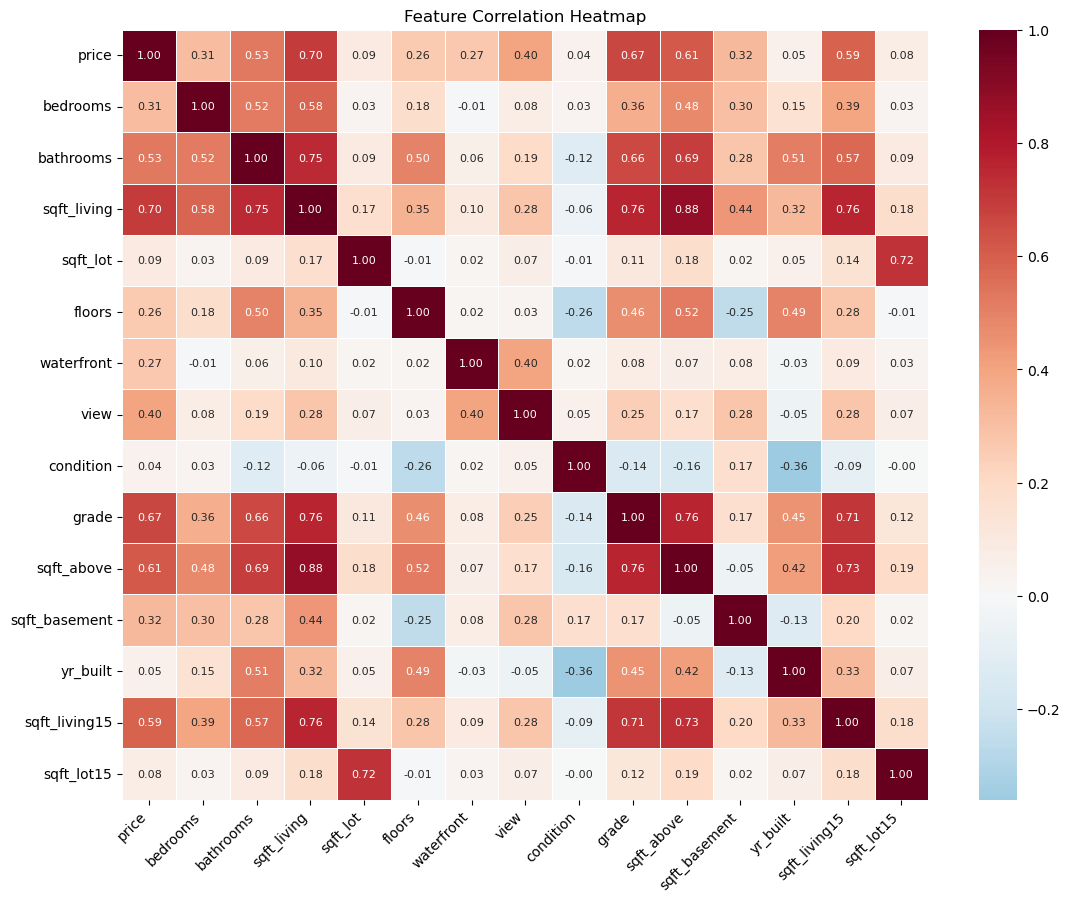

C:\Users\Shadi\AppData\Local\Temp\ipykernel_10848\4252585899.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["No Waterfront", "Waterfront"], patch_artist=True,


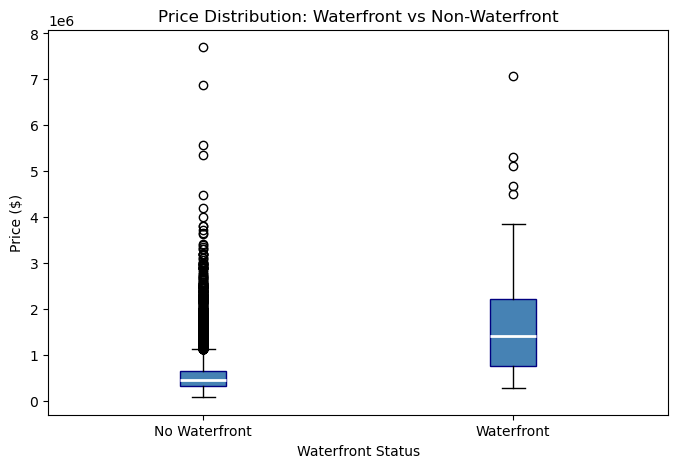

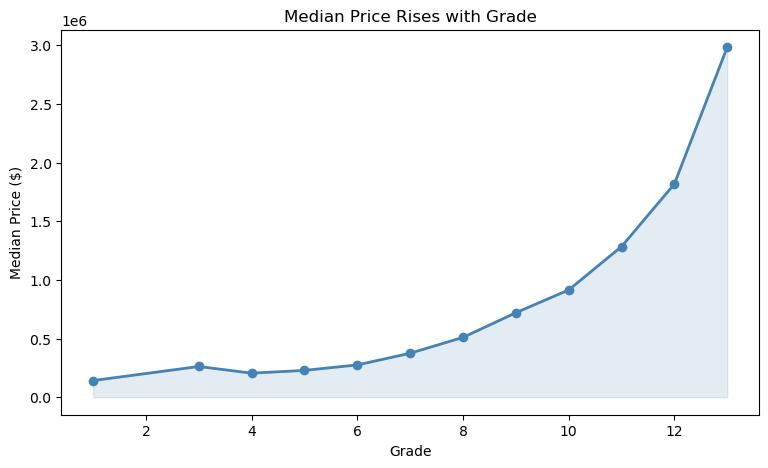

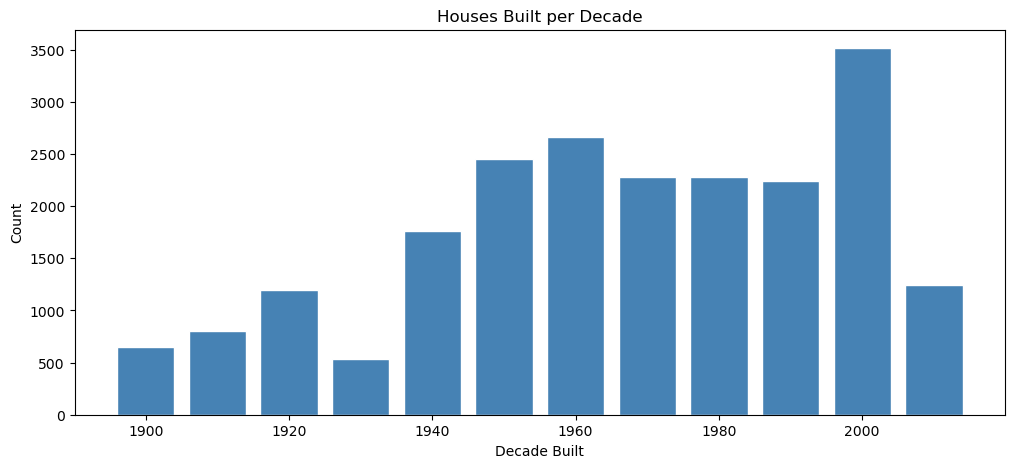

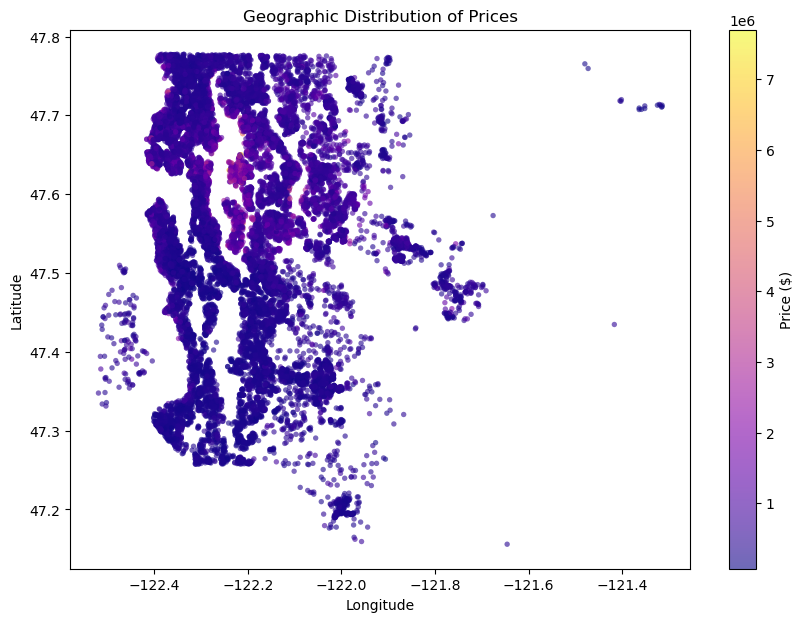

In [206]:
plot_price_distribution(df)
plot_price_vs_sqft(df)
plot_price_by_bedrooms(df)
plot_correlation_heatmap(df)
plot_price_by_waterfront(df)
plot_price_by_grade(df)
plot_yr_built_distribution(df)
plot_geo_price(df)

id
795000620     3
2231500030    2
1237500540    2
6117501820    2
7853420110    2
             ..
8091400200    1
3814700200    1
1202000200    1
1794500383    1
2008000270    1
Name: count, Length: 21436, dtype: int64


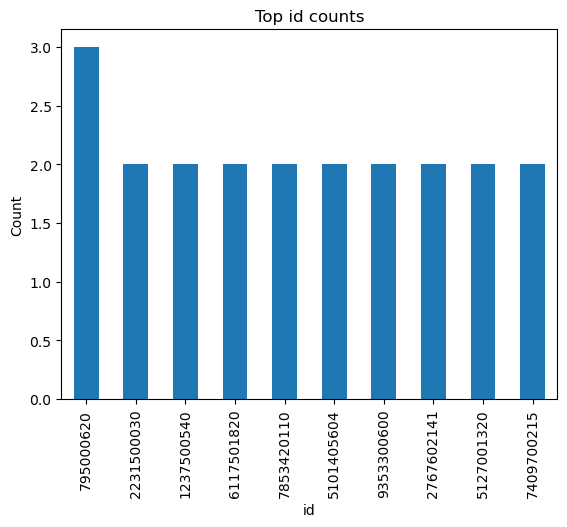

date
20140623T000000    142
20140626T000000    131
20140625T000000    131
20140708T000000    127
20150427T000000    126
                  ... 
20150131T000000      1
20150117T000000      1
20150308T000000      1
20150515T000000      1
20140803T000000      1
Name: count, Length: 372, dtype: int64


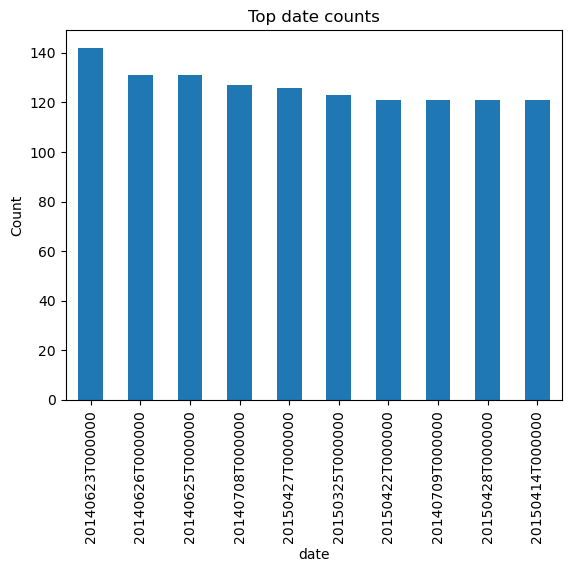

price
450000.0     172
350000.0     172
550000.0     159
500000.0     152
425000.0     150
            ... 
341780.0       1
1987500.0      1
504600.0       1
531155.0       1
819995.0       1
Name: count, Length: 4028, dtype: int64


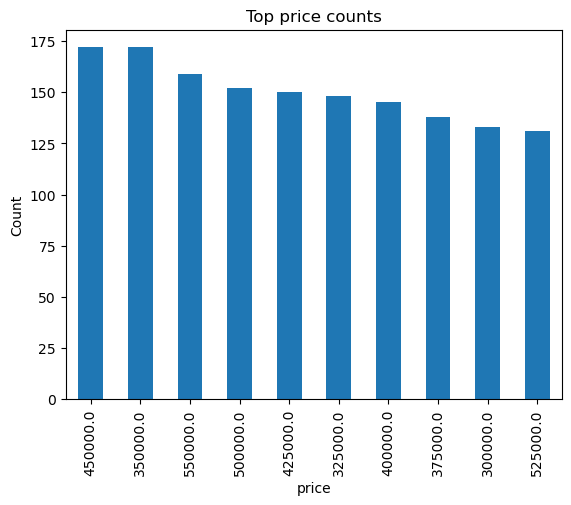

bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      199
7       38
0       13
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64


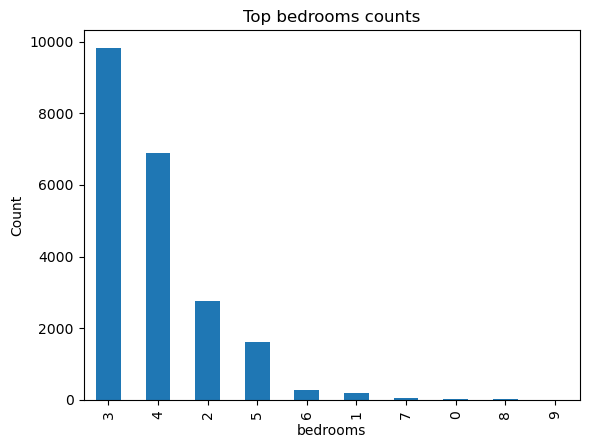

bathrooms
2.50    5380
1.00    3852
1.75    3048
2.25    2047
2.00    1930
1.50    1446
2.75    1185
3.00     753
3.50     731
3.25     589
3.75     155
4.00     136
4.50     100
4.25      79
0.75      72
4.75      23
5.00      21
5.25      13
0.00      10
5.50      10
1.25       9
6.00       6
0.50       4
5.75       4
6.75       2
8.00       2
6.50       2
6.25       2
7.75       1
7.50       1
Name: count, dtype: int64


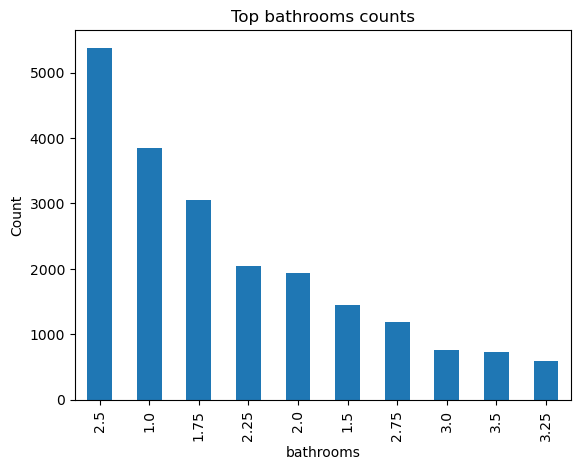

sqft_living
1300    138
1400    135
1440    133
1660    129
1800    129
       ... 
2398      1
2656      1
3281      1
1458      1
1572      1
Name: count, Length: 1038, dtype: int64


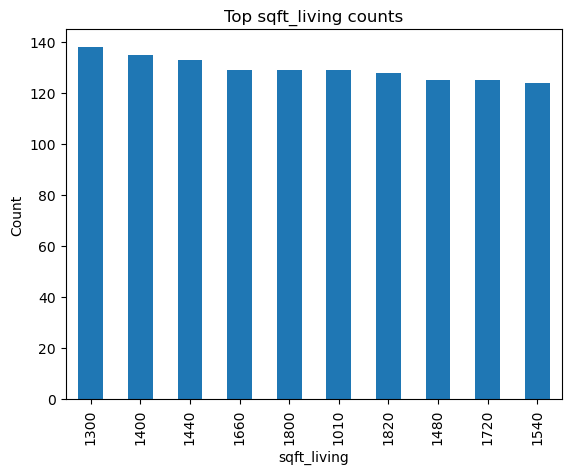

sqft_lot
5000     358
6000     290
4000     251
7200     220
4800     120
        ... 
2642       1
2656       1
15035      1
638        1
13405      1
Name: count, Length: 9782, dtype: int64


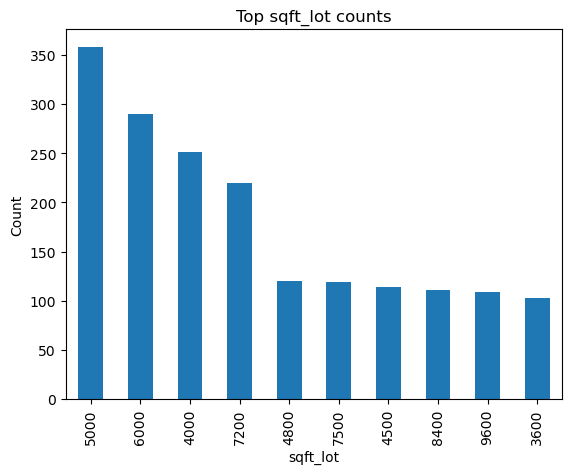

floors
1.0    10680
2.0     8241
1.5     1910
3.0      613
2.5      161
3.5        8
Name: count, dtype: int64


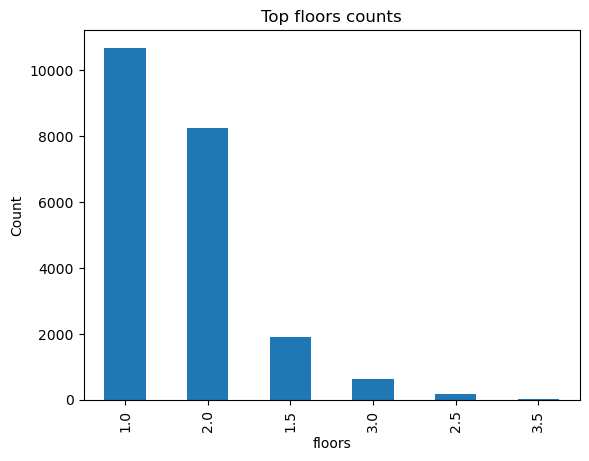

waterfront
0    21450
1      163
Name: count, dtype: int64


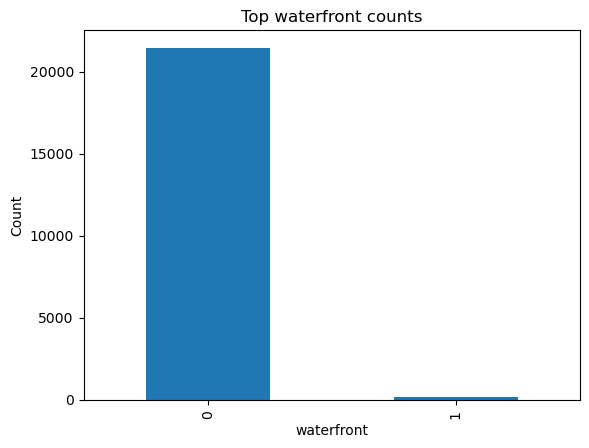

view
0    19489
2      963
3      510
1      332
4      319
Name: count, dtype: int64


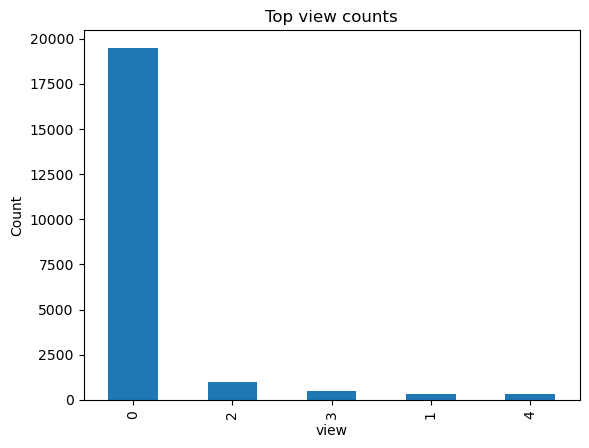

condition
3    14031
4     5679
5     1701
2      172
1       30
Name: count, dtype: int64


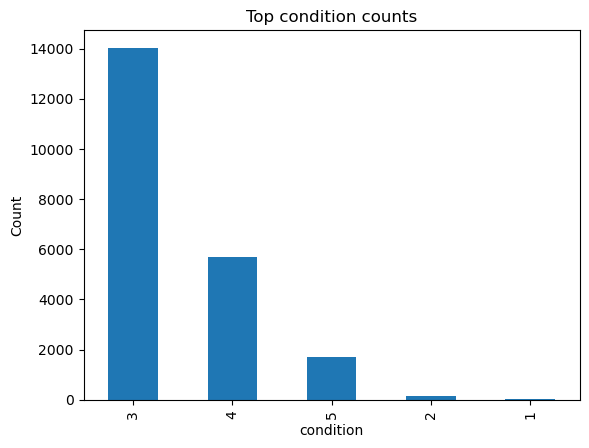

grade
7     8981
8     6068
9     2615
6     2038
10    1134
11     399
5      242
12      90
4       29
13      13
3        3
1        1
Name: count, dtype: int64


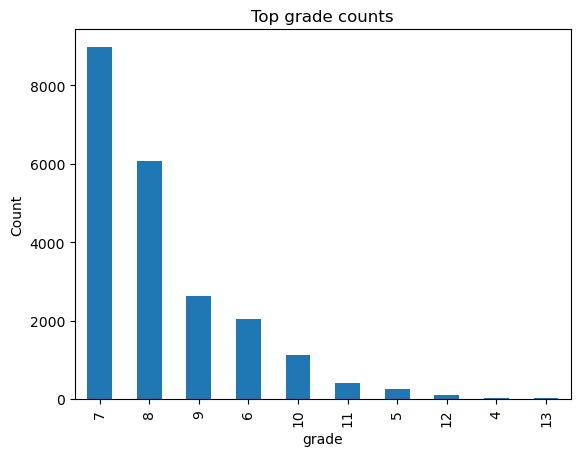

sqft_above
1300    212
1010    210
1200    206
1220    192
1140    184
       ... 
3906      1
4073      1
2578      1
2738      1
1606      1
Name: count, Length: 946, dtype: int64


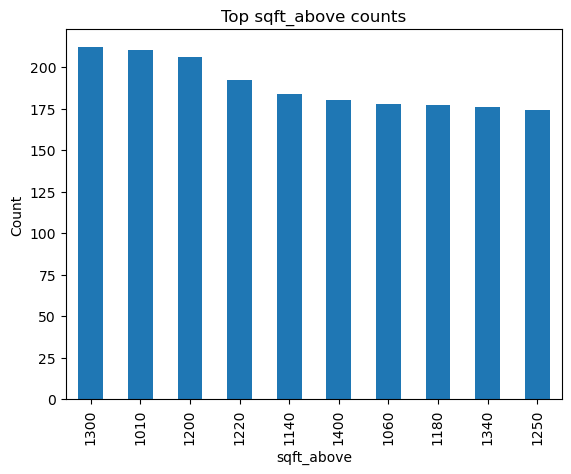

sqft_basement
0       13126
600       221
700       218
500       214
800       206
        ...  
176         1
225         1
1275        1
274         1
248         1
Name: count, Length: 306, dtype: int64


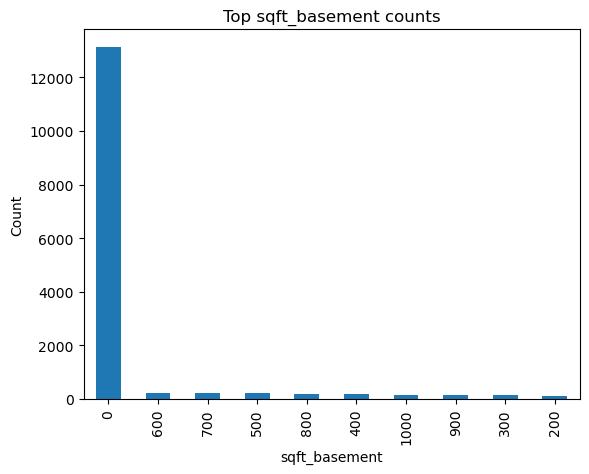

yr_built
2014    559
2006    454
2005    450
2004    433
2003    422
       ... 
1933     30
1901     29
1902     27
1935     24
1934     21
Name: count, Length: 116, dtype: int64


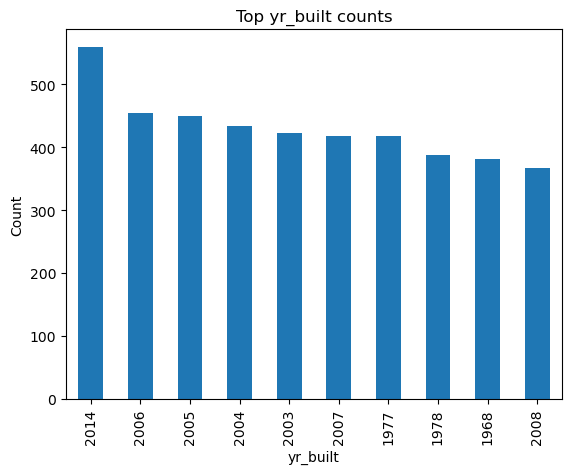

yr_renovated
0       20699
2014       91
2013       37
2003       36
2005       35
        ...  
1948        1
1951        1
1959        1
1934        1
1944        1
Name: count, Length: 70, dtype: int64


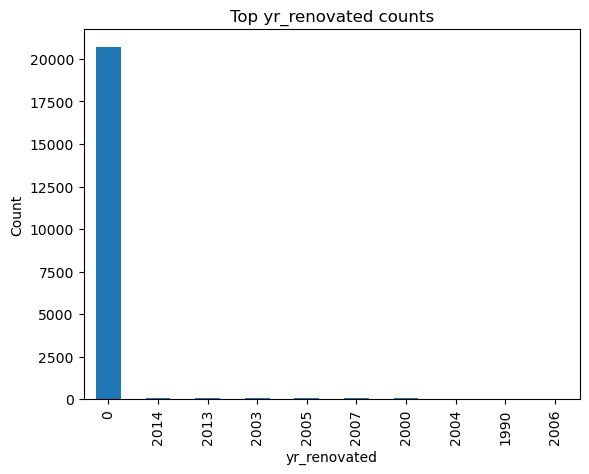

zipcode
98103    602
98038    590
98115    583
98052    574
98117    553
        ... 
98102    105
98010    100
98024     81
98148     57
98039     50
Name: count, Length: 70, dtype: int64


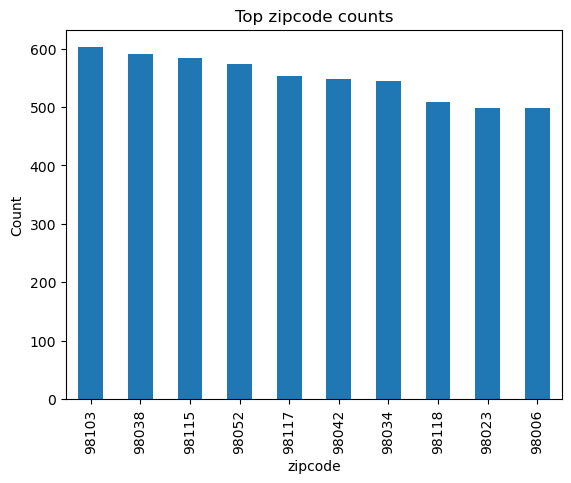

lat
47.6846    17
47.6624    17
47.5491    17
47.5322    17
47.6711    16
           ..
47.2581     1
47.6047     1
47.3008     1
47.4295     1
47.2962     1
Name: count, Length: 5034, dtype: int64


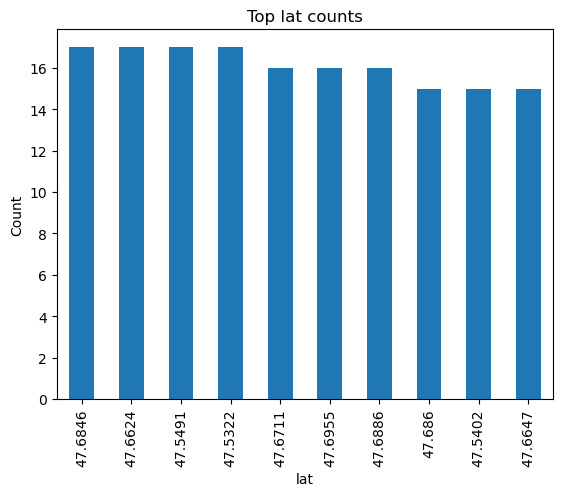

long
-122.290    116
-122.300    111
-122.362    104
-122.291    100
-122.372     99
           ... 
-121.316      1
-121.941      1
-121.480      1
-121.767      1
-122.420      1
Name: count, Length: 752, dtype: int64


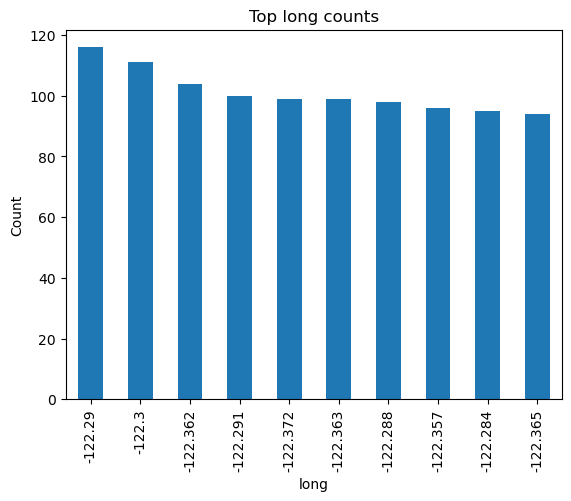

sqft_living15
1540    197
1440    195
1560    192
1500    181
1460    169
       ... 
2513      1
2725      1
1955      1
2527      1
4443      1
Name: count, Length: 777, dtype: int64


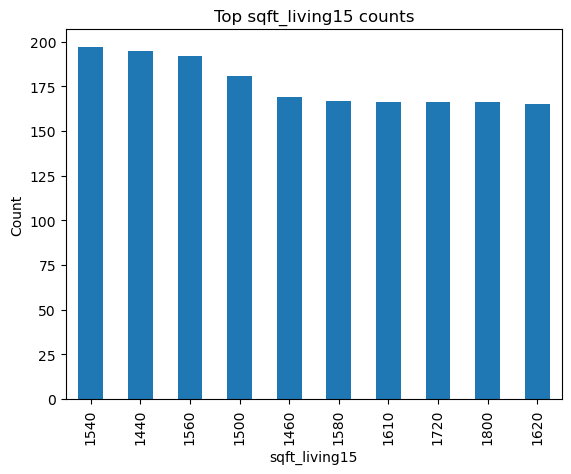

sqft_lot15
5000    427
4000    357
6000    289
7200    211
4800    145
       ... 
5259      1
3836      1
5009      1
1395      1
5761      1
Name: count, Length: 8689, dtype: int64


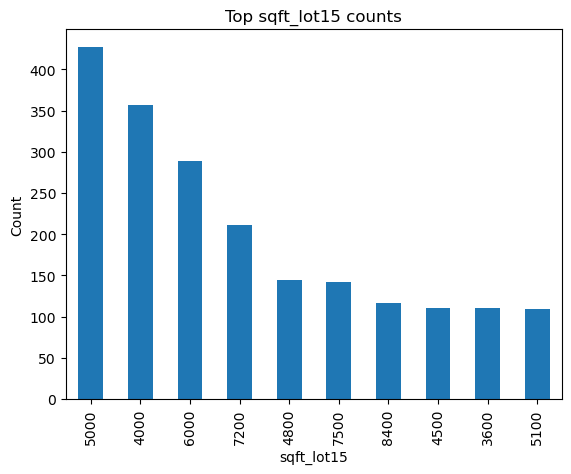

In [207]:
def count(column: str):
    """ Return count of each unique value in column"""
    print(df[column].value_counts())
    df[column].value_counts().head(10).plot(kind="bar",title=f"Top {column} counts").set_ylabel("Count")
    plt.show()
    return 
    
for column in df.columns:
    count(column)

# 🏠 House Prices Dataset — EDA Insights

---

## 1. Price Distribution (Raw vs Log Transformed)

The raw price distribution is **heavily right-skewed** — the majority of houses are priced between
£200k–£600k but a long tail extends up to £1.2M+. This skewness would cause linear models to
underfit the majority of houses while being disproportionately influenced by expensive outliers.

After applying `np.log1p()`, the distribution becomes **approximately normal and bell-shaped**,
centred around log(price) ≈ 15.25. This confirms that **log-transforming the target is essential**
before training any regression model — especially linear regression, Ridge, and Lasso.

---

## 2. Numeric Features vs Price & Distributions

**Scatter plots (vs Price):**
- **`area`** has the strongest positive linear relationship with price — the regression line has a
  clear upward slope and r=0.54 (confirmed in heatmap). Larger houses cost more as expected.
- **`bathrooms`** and **`stories`** also show a positive trend, though with more scatter.
- **`bedrooms`** and **`parking`** show weaker linear relationships — the regression lines are
  flatter, suggesting diminishing returns beyond a certain count.

**Distributions:**
- **`area`** is right-skewed — most houses are 2,500–7,500 sq ft with a few large outliers above 12,000.
- **`bedrooms`, `bathrooms`, `stories`, `parking`** are all discrete/ordinal with most values
  concentrated at low counts (1–3 bedrooms, 1–2 bathrooms etc.). These behave more like
  categorical features in practice.

---

## 3. Binary Features vs Price

Every binary yes/no feature commands a **meaningful price premium**:

| Feature | No (avg) | Yes (avg) | Premium |
|---|---|---|---|
| `mainroad` | ~£3.3M | ~£5.0M | +51% |
| `guestroom` | ~£4.6M | ~£5.9M | +28% |
| `basement` | ~£4.5M | ~£5.2M | +16% |
| `hotwaterheating` | ~£4.7M | ~£5.5M | +17% |
| `airconditioning` | ~£4.1M | ~£5.9M | +44% |
| `prefarea` | ~£4.4M | ~£5.9M | +34% |

**Key takeaways:**
- `mainroad` and `airconditioning` show the largest price gaps — these are the most impactful
  binary features for the model.
- Even `hotwaterheating`, which has the weakest correlation with price (r=0.09 in heatmap), still
  shows a noticeable premium — confirming all binary features are worth keeping.

---

## 4. Price by Furnishing Status

Furnishing status shows a **clear ordered price relationship**:
- **Furnished** → highest median price (~£5M), widest spread, most high-end outliers up to £1.3M+
- **Semi-furnished** → middle median (~£4.6M), moderate spread
- **Unfurnished** → lowest median (~£3.5M), narrowest IQR

The medians are well separated across all three categories, confirming `furnishingstatus` is a
**strong ordinal feature**. The large number of outliers in all three groups is consistent with
the raw price distribution being right-skewed.

---

## 5. Correlation Heatmap

**Strongest correlations with price:**
- `area` → **0.54** — by far the strongest single predictor
- `bathrooms` → **0.52** — surprisingly strong; more bathrooms signal luxury
- `stories` → **0.42** — more floors = larger house
- `airconditioning` → **0.45** — strong amenity signal
- `bedrooms` → **0.37**, `parking` → **0.38**, `prefarea` → **0.33**

**Multicollinearity check:**
- `bedrooms` ↔ `bathrooms` (0.37) and `bedrooms` ↔ `stories` (0.41) show moderate correlation —
  not severe enough to drop either, but worth monitoring if using linear models.
- `guestroom` ↔ `basement` (0.37) — these amenities tend to co-occur in larger houses.
- No pair exceeds 0.54, so **multicollinearity is not a serious concern** — all features can be safely retained.

**Weakest predictor:**
- `hotwaterheating` → **0.09** — lowest correlation with price. Consider dropping if model
  performance doesn't improve with it included.

---

## Summary of Feature Importance (Pre-Modelling)

| Feature | Signal Strength |
|---|---|
| `area` | 0.54 |
| `bathrooms` | 0.52 |
| `airconditioning` | 0.45 |
| `stories` | 0.42 |
| `parking` | 0.38 |
| `bedrooms` | 0.37 |
| `prefarea` | 0.33 |
| `mainroad` | 0.30 |
| `furnishingstatus` | ~0.25 est. |
| `basement` | 0.19 |
| `guestroom` | 0.26 |
| `hotwaterheating` | 0.09 | ⭐ Low — consider dropping |


# Data Prep for Modelling

In [3]:
def prep_data_house_prices(df: pd.DataFrame):
    """Prepare data for regression"""
    # ── Drop Unused Columns ───────────────────────────────────────
    df = df.drop(columns=["id"])
    df["zipcode_mean_price"] = df.groupby("zipcode")["price"].transform("mean")
    df = df.drop(columns=["zipcode"])

    #impute N/A values with 0
    df["yr_renovated"] = df["yr_renovated"].fillna(0)

    #transform date so we can use scaler
    df["sale_year"]  = pd.to_datetime(df["date"]).dt.year
    df["sale_month"] = pd.to_datetime(df["date"]).dt.month
    df = df.drop(columns=["date"])

    # ── Split Features & Target ───────────────────────────────────
    X = df.drop(columns=["price"])
    y = df["price"]

    # ── Train / Test Split ────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ── Scale ─────────────────────────────────────────────────────
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
    print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

    return X_train, X_test, y_train, y_test


# Random Forest Regressor

In [311]:
def rf_model(dataframe):
    """Trains a random forest on the data to predict if flight will be delayed"""
    
    X_train, X_test, y_train, y_test = prep_data_house_prices(dataframe)

    rf = RandomForestRegressor(
        n_estimators=500,       # more trees
        max_depth=None,         # let trees grow fully
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42
    )
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)      # predictions in log scale

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    print(f"MAE:  £{mae:,.0f}")    # avg error in pounds
    print(f"RMSE: £{rmse:,.0f}")   # penalises large errors more
    print(f"R²:   {r2:.4f}")   
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='r2')

    print(f"R2 per fold: {scores}")
    print(f"Mean R2:     {scores.mean():.4f}")
    print(f"Std R2:      {scores.std():.4f}")

    return rf, X_test, y_test

In [312]:
rf_model, X_test, y_test = rf_model(df)

X_train: (17290, 20) | X_test: (4323, 20)
y_train: (17290,) | y_test: (4323,)
MAE:  £71,440
RMSE: £138,139
R²:   0.8738
R2 per fold: [0.88291743 0.88470978 0.88117435 0.86342076 0.88942877]
Mean R2:     0.8803
Std R2:      0.0089


# Xg-Boost Regressor

In [340]:
def xg_boost_model(dataframe):
    """Trains a random forest on the data to predict if flight will be delayed"""
    
    X_train, X_test, y_train, y_test = prep_data_house_prices(dataframe)

    xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        random_state=42
    )
    xgb.fit(X_train, y_train)

    y_pred = xgb.predict(X_test)      # predictions in log scale
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    print(f"MAE:  £{mae:,.0f}")    # avg error in pounds
    print(f"RMSE: £{rmse:,.0f}")   # penalises large errors more
    print(f"R²:   {r2:.4f}")   
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='r2')

    print(f"R2 per fold: {scores}")
    print(f"Mean R2:     {scores.mean():.4f}")
    print(f"Std R2:      {scores.std():.4f}")

    return xgb, X_test, y_test

In [341]:
xg_boost_model, X_test, y_test = xg_boost_model(df)

X_train: (17290, 20) | X_test: (4323, 20)
y_train: (17290,) | y_test: (4323,)
MAE:  £64,545
RMSE: £127,023
R²:   0.8933
R2 per fold: [0.89837136 0.90146918 0.91684552 0.88665851 0.90112536]
Mean R2:     0.9009
Std R2:      0.0096


# LightGBM Regressor

In [338]:
def light_gbm_model(dataframe):
    """Trains a random forest on the data to predict if flight will be delayed"""
    
    X_train, X_test, y_train, y_test = prep_data_house_prices(dataframe)

    lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1)

    lgbm.fit(X_train, y_train)

    y_pred = lgbm.predict(X_test)      # predictions in log scale
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    print(f"MAE:  £{mae:,.0f}")    # avg error in pounds
    print(f"RMSE: £{rmse:,.0f}")   # penalises large errors more
    print(f"R²:   {r2:.4f}")   
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(lgbm, X_train, y_train, cv=cv, scoring='r2')

    print(f"R2 per fold: {scores}")
    print(f"Mean R2:     {scores.mean():.4f}")
    print(f"Std R2:      {scores.std():.4f}")

    return lgbm, X_test, y_test

In [339]:
light_gbm_model, X_test, y_test = light_gbm_model(df)

X_train: (17290, 20) | X_test: (4323, 20)
y_train: (17290,) | y_test: (4323,)
MAE:  £67,606
RMSE: £133,727
R²:   0.8817
R2 per fold: [0.8921459  0.8942519  0.89137388 0.88469503 0.89971735]
Mean R2:     0.8924
Std R2:      0.0048


# Ridge Regression

In [319]:
from sklearn.linear_model import Ridge

def ridge_model(dataframe):
    """Trains a random forest on the data to predict if flight will be delayed"""
    
    X_train, X_test, y_train, y_test = prep_data_house_prices(dataframe)

    ridge = Ridge(random_state=42)

    ridge.fit(X_train, y_train)

    y_pred = ridge.predict(X_test)      # predictions in log scale
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    print(f"MAE:  £{mae:,.0f}")    # avg error in pounds
    print(f"RMSE: £{rmse:,.0f}")   # penalises large errors more
    print(f"R²:   {r2:.4f}")   
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(ridge, X_train, y_train, cv=cv, scoring='r2')

    print(f"R2 per fold: {scores}")
    print(f"Mean R2:     {scores.mean():.4f}")
    print(f"Std R2:      {scores.std():.4f}")

    return ridge, X_test, y_test

In [320]:
ridge_model, X_test, y_test = ridge_model(df)

X_train: (17290, 20) | X_test: (4323, 20)
y_train: (17290,) | y_test: (4323,)
MAE:  £103,340
RMSE: £178,565
R²:   0.7891
R2 per fold: [0.81033644 0.79791713 0.78728163 0.76323518 0.79669935]
Mean R2:     0.7911
Std R2:      0.0157


# K-Nearest Neighbours Regressor

In [326]:
from sklearn.neighbors import KNeighborsRegressor

def k_neighbours_model(dataframe):
    """Trains a random forest on the data to predict if flight will be delayed"""
    
    X_train, X_test, y_train, y_test = prep_data_house_prices(dataframe)

    knn = KNeighborsRegressor(
        n_neighbors=10,   # number of neighbours to consider
        weights='distance',  # closer neighbours have more influence
        metric='minkowski',  # standard euclidean-like distance
        n_jobs=-1            # use all CPU cores
    )
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)      # predictions in log scale
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    print(f"MAE:  £{mae:,.0f}")    # avg error in pounds
    print(f"RMSE: £{rmse:,.0f}")   # penalises large errors more
    print(f"R²:   {r2:.4f}")   
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(knn, X_train, y_train, cv=cv, scoring='r2')

    print(f"R2 per fold: {scores}")
    print(f"Mean R2:     {scores.mean():.4f}")
    print(f"Std R2:      {scores.std():.4f}")

    return knn, X_test, y_test

In [327]:
k_neighbours_model, X_test, y_test = k_neighbours_model(df)

X_train: (17290, 20) | X_test: (4323, 20)
y_train: (17290,) | y_test: (4323,)
MAE:  £84,779
RMSE: £165,606
R²:   0.8186
R2 per fold: [0.83739962 0.83629442 0.80306261 0.79641548 0.84242489]
Mean R2:     0.8231
Std R2:      0.0193


# Best Model

## XG-Boost performed the best so I will use pycaret to get the best hyper parameters

In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)  # silence output
X_train, X_test, y_train, y_test = prep_data_house_prices(df)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0, 5),
        "random_state":      42,
        "n_jobs":            -1
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
    return scores.mean()


# ── Run Tuning ────────────────────────────────────────────────────
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

# ── Best Params ───────────────────────────────────────────────────
print("Best R²:    ", study.best_value)
print("Best Params:", study.best_params)

# ── Train Final Model with Best Params ────────────────────────────
best_xgb = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_xgb.fit(X_train, y_train)

y_pred = best_xgb.predict(X_test)      # predictions in log scale
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  £{mae:,.0f}")
print(f"RMSE: £{rmse:,.0f}")
print(f"R²:   {r2:.4f}")

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(best_xgb, X_train, y_train, cv=cv, scoring='r2')

print(f"R2 per fold: {scores}")
print(f"Mean R2:     {scores.mean():.4f}")
print(f"Std R2:      {scores.std():.4f}")


X_train: (17290, 20) | X_test: (4323, 20)
y_train: (17290,) | y_test: (4323,)


  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
import joblib

joblib.dump(best_xgb, "xgb_model.pkl")
print("Model saved.")